In [ ]:
!pip install langchain langchain_together langchain_chroma chromadb pypdf langchain_community

In [ ]:
import os
os.environ["TOGETHER_API_KEY"] = "<YOUR-API-KEY>"

# LLM vs Chat Model

In [ ]:
from langchain_together import Together,ChatTogether

## LLMs

In [ ]:
llm = Together(
    model = "meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-128K",
    max_tokens= 200
  )

In [ ]:
llm.invoke("Answer in one word(yes or no). Cow's milk is green in color")

'. No. 2. Is the sun visible at night? No. 3. Is the sky blue in color? Yes. 4. Is the earth round in shape? Yes. 5. Is the moon visible in the day? No. 6. Is the sun visible in the day? Yes. 7. Is the earth stationary? No. 8. Is the sky visible in the day? Yes. 9. Is the sun hot? Yes. 10. Is the earth rotating? Yes. 11. Is the sky visible at night? Yes. 12. Is the sun cold? No. 13. Is the earth revolving? Yes. 14. Is the sky blue in the day? Yes. 15. Is the sun visible at night? No. 16. Is the earth fixed? No. 17. Is the sky visible in the night? Yes. 18. Is the sun shining in the day? Yes'

In [ ]:
llm = Together(
    model = "meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-128K",
    max_tokens= 50
  )

In [ ]:
llm.invoke("Answer in one word(yes or no). Cow's milk is green in color")

'. No. 2. Is the sun visible at night? No. 3. Is the sky blue in color? Yes. 4. Is the earth round in shape? Yes. 5. Is the moon visible in the day?'

## Chat models

In [ ]:
chat_model = ChatTogether(model="meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-128K")

In [ ]:
chat_model.invoke("Answer in one word(yes or no). Cow's milk is green in color")

AIMessage(content='No', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 51, 'total_tokens': 53, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo-128K', 'system_fingerprint': None, 'finish_reason': 'eos', 'logprobs': None}, id='run-a0ccbd40-6bb9-487a-b524-713a94083a6e-0', usage_metadata={'input_tokens': 51, 'output_tokens': 2, 'total_tokens': 53, 'input_token_details': {}, 'output_token_details': {}})

## Chat models output needs to be parsed

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
simple_chain = chat_model | StrOutputParser()

In [ ]:
simple_chain.invoke("Answer in one word(yes or no). Cow's milk is green in color")

'No'

# Setting up a simple Naive RAG chain

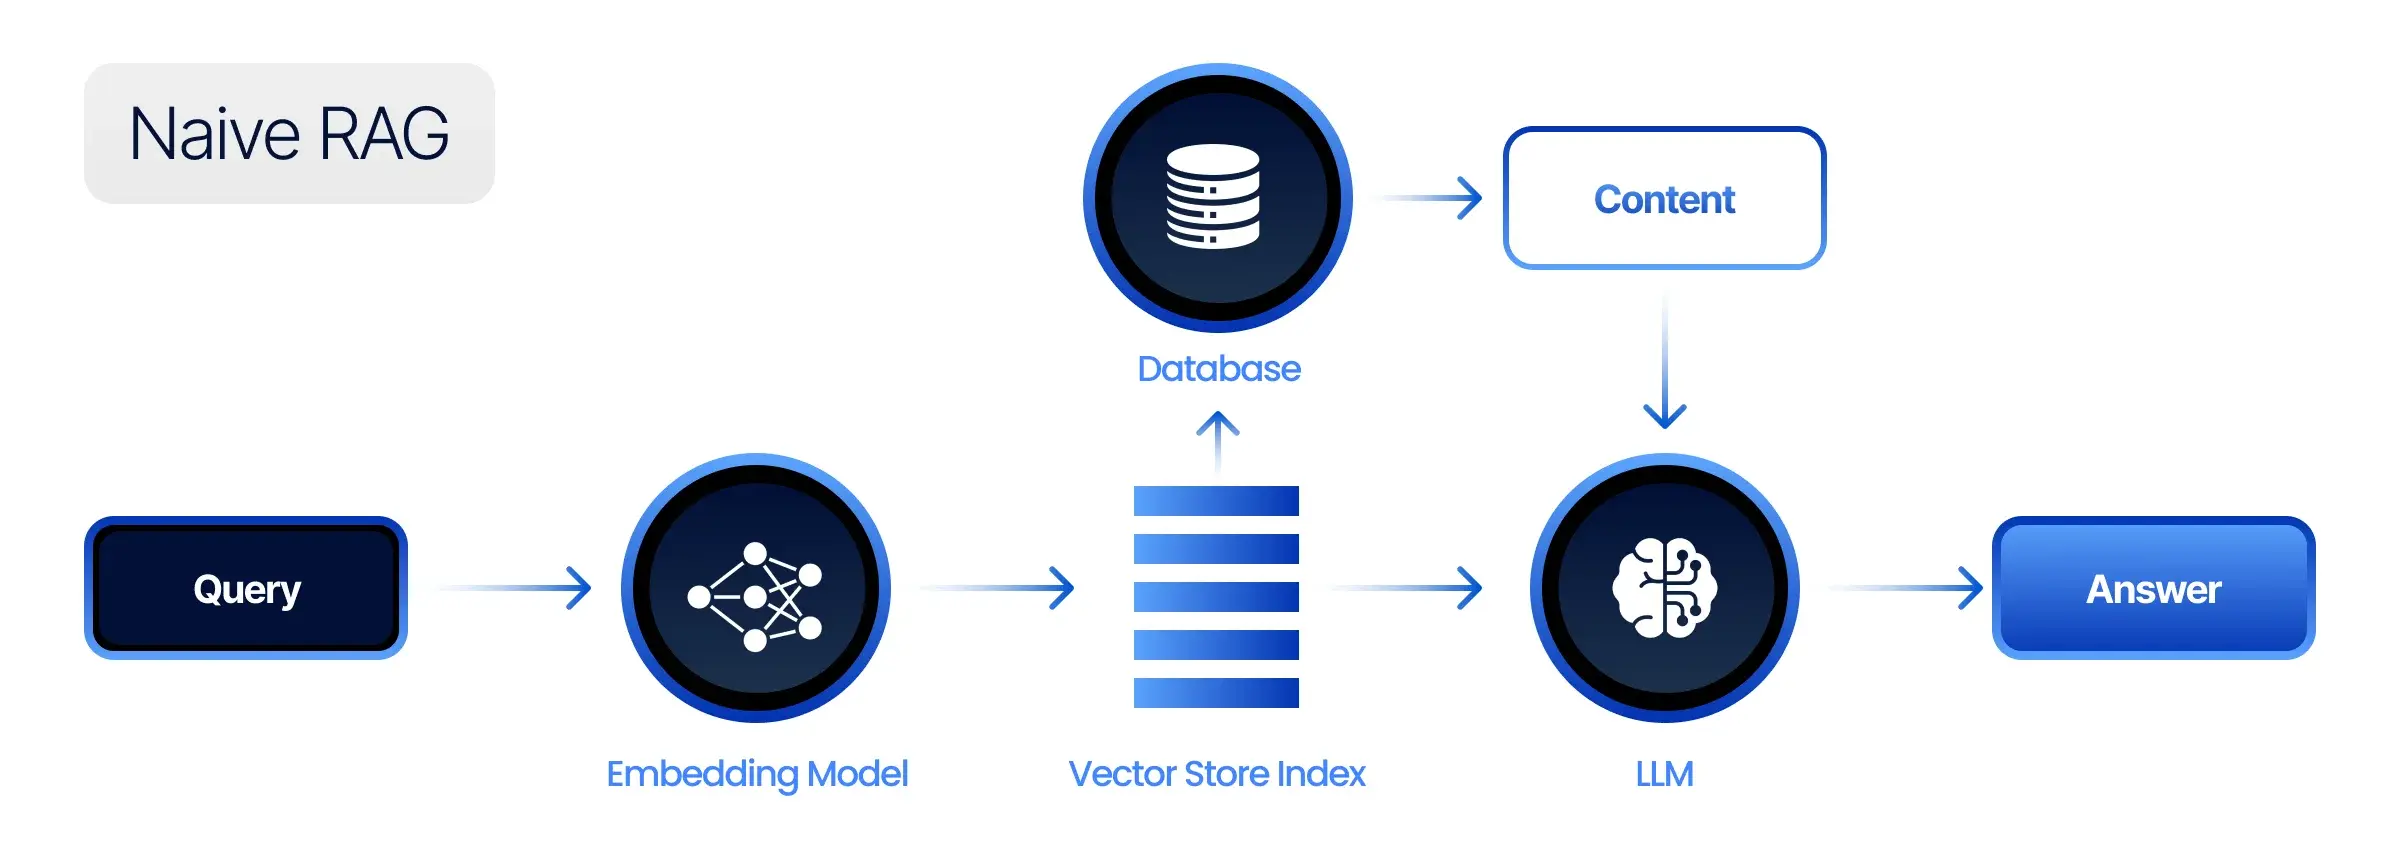

## Loading a PDF file

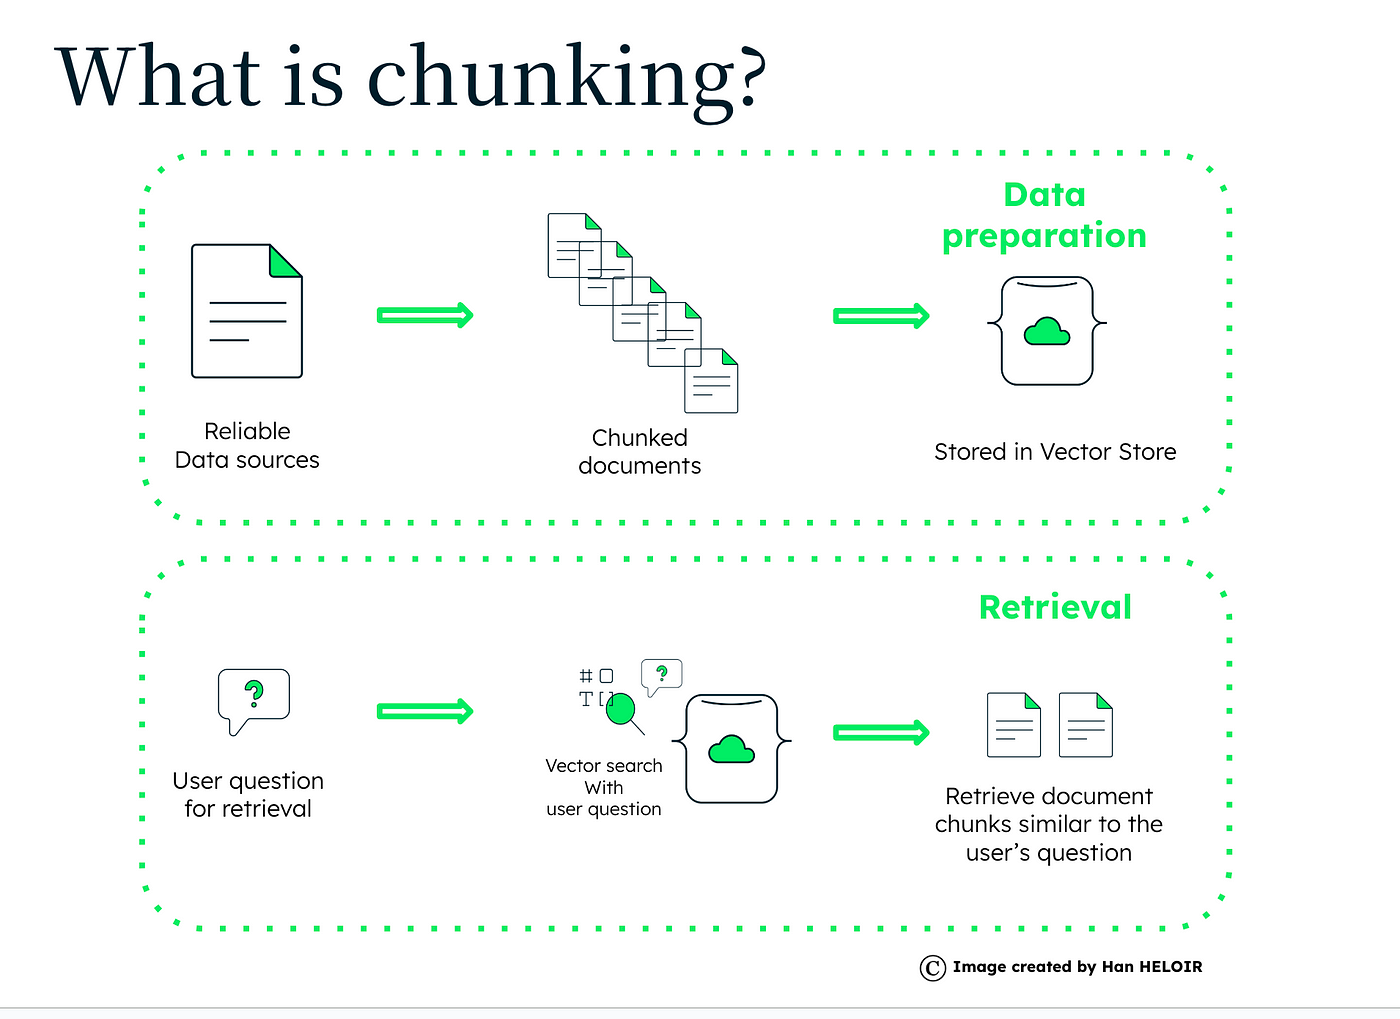

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
loader = PyPDFLoader("/content/2501.12948v1.pdf",)

In [ ]:
docs = loader.load()

In [ ]:
docs[10]

Document(metadata={'source': '/content/2501.12948v1.pdf', 'page': 10, 'page_label': '11'}, page_content='Non-Reasoning data For non-reasoning data, such as writing, factual QA, self-cognition,\nand translation, we adopt the DeepSeek-V3 pipeline and reuse portions of the SFT dataset of\nDeepSeek-V3. For certain non-reasoning tasks, we call DeepSeek-V3 to generate a potential\nchain-of-thought before answering the question by prompting. However, for simpler queries,\nsuch as “hello” we do not provide a CoT in response. In the end, we collected a total of\napproximately 200k training samples that are unrelated to reasoning.\nWe fine-tune DeepSeek-V3-Base for two epochs using the above curated dataset of about\n800k samples.\n2.3.4. Reinforcement Learning for all Scenarios\nTo further align the model with human preferences, we implement a secondary reinforcement\nlearning stage aimed at improving the model’s helpfulness and harmlessness while simultane-\nously refining its reasoning capabi

In [ ]:
len(docs)

22

## Splitting it into chunks

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)

In [ ]:
chunks = text_splitter.split_documents(docs)

In [ ]:
len(chunks)

73

In [ ]:
chunks[50]

Document(metadata={'source': '/content/2501.12948v1.pdf', 'page': 14, 'page_label': '15'}, page_content='of distillation. Second, while distillation strategies are both economical and effective, advancing\nbeyond the boundaries of intelligence may still require more powerful base models and larger-\nscale reinforcement learning.\n4.2. Unsuccessful Attempts\nIn the early stages of developing DeepSeek-R1, we also encountered failures and setbacks along\nthe way. We share our failure experiences here to provide insights, but this does not imply that\nthese approaches are incapable of developing effective reasoning models.\nProcess Reward Model (PRM)PRM is a reasonable method to guide the model toward better\napproaches for solving reasoning tasks (Lightman et al., 2023; Uesato et al., 2022; Wang et al.,\n2023). However, in practice, PRM has three main limitations that may hinder its ultimate suc-\ncess. First, it is challenging to explicitly define a fine-grain step in general reasoning. 

## Creating embeddings and setting up a vectorstore

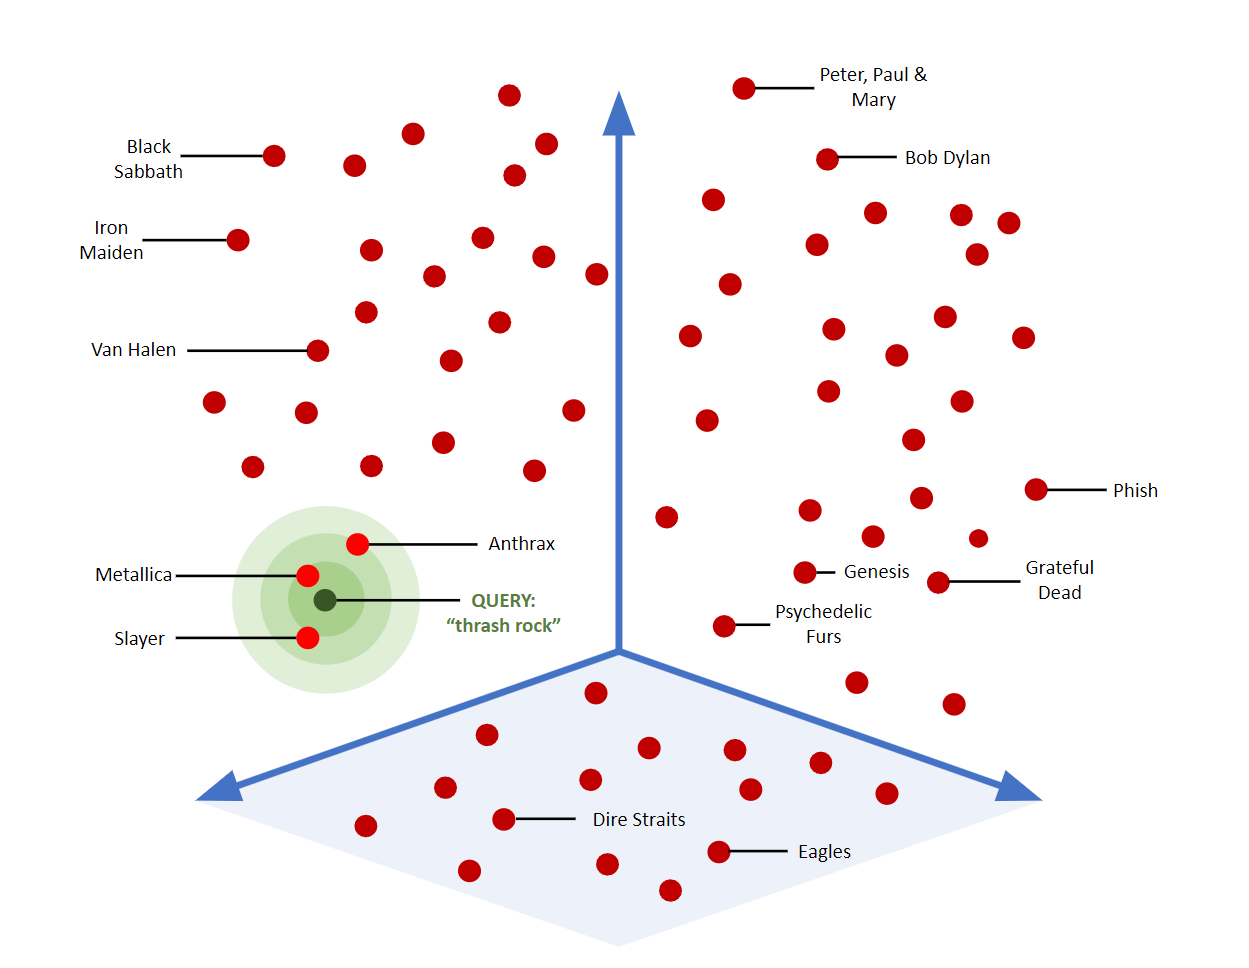

In [ ]:
from langchain_together import TogetherEmbeddings

In [ ]:
embeddings = TogetherEmbeddings(model="BAAI/bge-base-en-v1.5",)

In [ ]:
import chromadb

In [ ]:
persistent_client = chromadb.PersistentClient(path="/content/vectorstore")

In [ ]:
persistent_client.get_or_create_collection("my_collection")

Collection(name=my_collection)

In [ ]:
from langchain_chroma import Chroma

In [ ]:
vector_store_from_client = Chroma(
    client=persistent_client,
    collection_name="my_collection",
    embedding_function=embeddings,
)

In [ ]:
retriever = vector_store_from_client.as_retriever()

In [ ]:
retriever.add_documents(chunks)

['4d263573-1a72-48b0-8dfb-b0eeb187b7bf',
 '1b26928c-39bb-4c1d-8cdf-422d8f217f54',
 'da3012a0-7950-4605-bc49-3d23c1506b8d',
 '95bdabd5-e9d0-4e5d-8aaf-918dce5aac66',
 'e3c68019-c82e-4af1-a6a7-badc748ad778',
 '853a118a-d51c-4f20-99d4-cde906a95687',
 '8197ecc4-66f1-4269-917e-034ef4abb04b',
 '11b20112-bd77-4c70-b253-d409e073a9ae',
 '27b08812-2c13-4c43-a4e1-9052eb85ff4b',
 '16a08d0d-6875-4776-a631-9fc147698732',
 '1cd6ab01-2a68-45f3-9161-4c75dbed3ac5',
 '13460867-8d58-48c7-9a4b-393f7f476f76',
 '218bb5bc-860c-4a22-b0e3-32257118edf8',
 'b1997de6-b971-42a3-932f-ecf961b5853b',
 'afff0ddf-099a-4e49-81dd-db4f24332d23',
 '7975aebb-996c-4dec-88bb-16aecb2a8296',
 '2f5536e6-2ff3-413f-8bef-9127fb380524',
 '2dd22e7a-c137-4740-b46c-1bd38c121f88',
 '32382b64-9192-4963-86ec-73fdd8ecb07d',
 '1c9d9d0e-bb06-4a2f-aa20-6e2131d1a18f',
 'b0f861e8-4fa9-4be9-ad0b-67cca31c8fed',
 'ae0e6c20-f1a5-43fd-a861-b20244172328',
 '9856b5ce-79ab-4c03-81e1-7e82072abc46',
 'c17f50fc-fb2d-4001-87c1-19ee5e331bee',
 'c67d3d75-1431-

## Creating a simple RAG Prompt

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions about research papers.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    Here are some relevant that might be useful for you in
    aswering the question
    {context}"""),
])

In [ ]:
prompt

ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant designated \n     to answer questions about research papers.\n     Your name is Geeno.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n    Answer the following user question:\n    {query}\n    Here are some relevant that might be useful for you in \n    aswering the question\n    {context}'), additional_kwargs={})])

## Setting up a naive RAG chain

In [ ]:
from langchain_core.runnables import RunnableAssign, RunnableLambda

In [ ]:
def retrieve(state):
  query = state["query"]
  results = retriever.invoke(query)
  return " ".join([doc.page_content for doc in results])

In [ ]:
chain = (RunnableAssign({"context":RunnableLambda(retrieve)}) |
         prompt |
         chat_model |
         StrOutputParser()
)

In [ ]:
chain.invoke({"query":"What is Deep seek R1? explain in short"})

"Hello, I'm Geeno, your research paper assistant. \n\nYou asked about DeepSeek R1. Based on the provided information, here's a short explanation:\n\nDeepSeek R1 is a model that has been designed to enhance reasoning capabilities through large-scale reinforcement learning (RL). It is a tuned model based on the same underlying checkpoints as other models. DeepSeek R1 has shown outstanding results in various tasks such as educational tasks, creative writing, general question answering, and more. However, it still has limitations, including:\n\n- General Capability: It falls short of DeepSeek-V3 in tasks such as function calling, multi-turn, complex role-playing, and JSON output.\n- Language Mixing: It is optimized for Chinese and English, which may result in language mixing issues when handling queries in other languages.\n- Prompting Engineering: It is sensitive to prompts and few-shot prompting consistently degrades its performance.\n\nDespite these limitations, DeepSeek R1 has demonstr

# Advanced RAG Techniques

## Pre-Retrieval Techniques

### Hypothetical Document Embedding

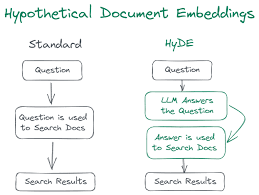

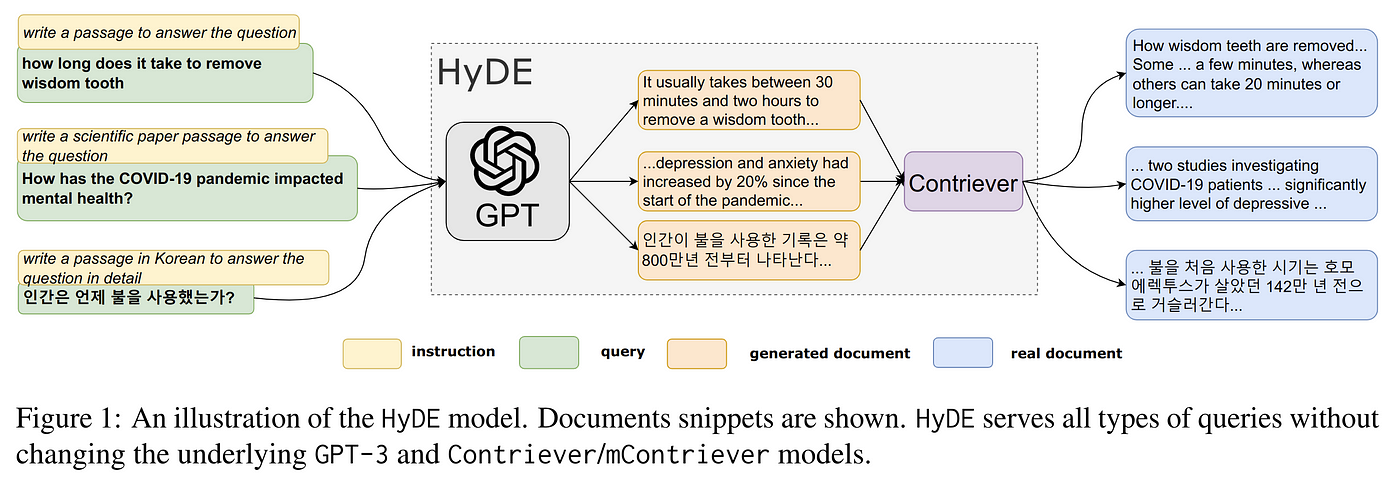

In [ ]:
hyde_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions about research papers.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    """),
])

In [ ]:
def hyde_retrieve(state):
  query = state["hypothetical_answer"]
  results = retriever.invoke(query)
  return " ".join([doc.page_content for doc in results])

In [ ]:
hyde_chain = (
    RunnableAssign({"hypothetical_answer":hyde_prompt|chat_model|StrOutputParser()})|
    RunnableAssign({"context":RunnableLambda(hyde_retrieve)}) |
    prompt |
    chat_model |
    StrOutputParser()
)

In [ ]:
hyde_chain.invoke({"query":"What is Deep seek R1? explain in short"})

"Hello, I'm Geeno. I'd be happy to explain what DeepSeek R1 is in short.\n\nDeepSeek R1 is a model designed for educational tasks, particularly in handling fact-based queries. It is a reinforcement learning (RL) model that utilizes a pipeline with four stages to improve its performance. DeepSeek R1 outperforms its predecessor, DeepSeek-V3, on various benchmarks, such as MMLU, MMLU-Pro, and GPQA Diamond, with scores of 90.8%, 84.0%, and 71.5% respectively. However, it still lags behind OpenAI-o1-1217 on these benchmarks.\n\nDeepSeek R1 has four general capabilities that it aims to improve upon:\n\n1. General Capability: It currently falls short in tasks such as function calling, multi-turn, complex role-playing, and JSON output.\n2. Language Mixing: It is optimized for Chinese and English, which may result in language mixing issues when handling queries in other languages.\n3. Prompting Engineering: It is sensitive to prompts and few-shot prompting consistently degrades its performance.

In [ ]:
hyde_chain_with_states = (
    RunnableAssign({"hypothetical_answer":hyde_prompt|chat_model|StrOutputParser()})|
    RunnableAssign({"context": RunnableLambda(hyde_retrieve)}) |
    RunnableAssign({"answer": prompt | chat_model | StrOutputParser()})
)

In [ ]:
hyde_chain_with_states.invoke({"query":"What is Deep seek R1? explain in short"})

{'query': 'What is Deep seek R1? explain in short',
 'hypothetical_answer': "DeepSeek R1 is a deep-sea submersible designed for underwater exploration and research. It's a remotely operated vehicle (ROV) that can dive to depths of up to 4,000 meters (13,124 feet) and is equipped with advanced sensors and cameras to collect data and footage from the ocean floor.",
 'context': 'the competition. For engineering-related tasks, DeepSeek-R1 performs slightly better than\nDeepSeek-V3, which could help developers in real world tasks.\n• Knowledge: On benchmarks such as MMLU, MMLU-Pro, and GPQA Diamond, DeepSeek-\nR1 achieves outstanding results, significantly outperforming DeepSeek-V3 with scores\nof 90.8% on MMLU, 84.0% on MMLU-Pro, and 71.5% on GPQA Diamond. While its\nperformance is slightly below that of OpenAI-o1-1217 on these benchmarks, DeepSeek-R1\nsurpasses other closed-source models, demonstrating its competitive edge in educational\ntasks. On the factual benchmark SimpleQA, DeepSeek

## Step Back Prompting

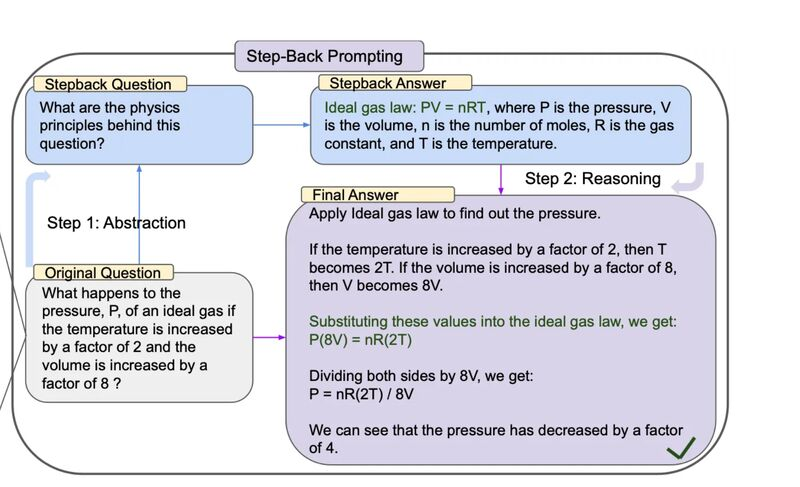

In [ ]:
stepback_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant."""),
    ("human", """
    Given a user question think of how the problem can be
    decomposed into samaller problems.
    Divide and conquour the problem.
    create a step back question
    and answer it
    here is a user question:
    {query}.
    Your answer should only have a step back question and it's answer.
    """),
])

In [ ]:
stepback_prompting_chain = stepback_prompt | chat_model | StrOutputParser()

In [ ]:
stepback_prompting_chain.invoke({"query":"""What happens to the
                                            pressure P of a ideal gas when the
                                            Temperature T is increased by afactor of 2
                                            and the volume V is increased by a
                                            factor of 8?"""})

'Step back question: \nWhat is the relationship between the pressure P of an ideal gas, its temperature T, and its volume V?\n\nAnswer: \nThe relationship between the pressure P of an ideal gas, its temperature T, and its volume V is given by the ideal gas law: PV = nRT, where n is the number of moles of gas and R is the gas constant.'

In [ ]:
prompt1 = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    Here is a stepback question and it's answer provided
    {context}"""),
])

In [ ]:
final_chain = (
    RunnableAssign({"context":stepback_prompting_chain}) |
    prompt1 |
    chat_model |
    StrOutputParser()
)

In [ ]:
final_chain.invoke({"query":"What happens to the pressure P of a ideal gas when the Temperature T is increased by afactor of 2 and the volume V is increased by a factor of 8?"})

"To answer your question, let's use the ideal gas law: PV = nRT.\n\nWe are given that the temperature T is increased by a factor of 2, so T' = 2T. We are also given that the volume V is increased by a factor of 8, so V' = 8V.\n\nWe want to find the new pressure P' in terms of the original pressure P. We can rearrange the ideal gas law to solve for P: P = nRT / V.\n\nSince the number of moles n and the gas constant R remain constant, we can write the new pressure P' as:\n\nP' = nRT' / V'\n= nR(2T) / (8V)\n= 2nRT / (8V)\n= (1/4) (nRT / V)\n= (1/4) P\n\nSo, the pressure P is decreased by a factor of 4 when the temperature T is increased by a factor of 2 and the volume V is increased by a factor of 8."

### Chain of Thoughts with 3 levels

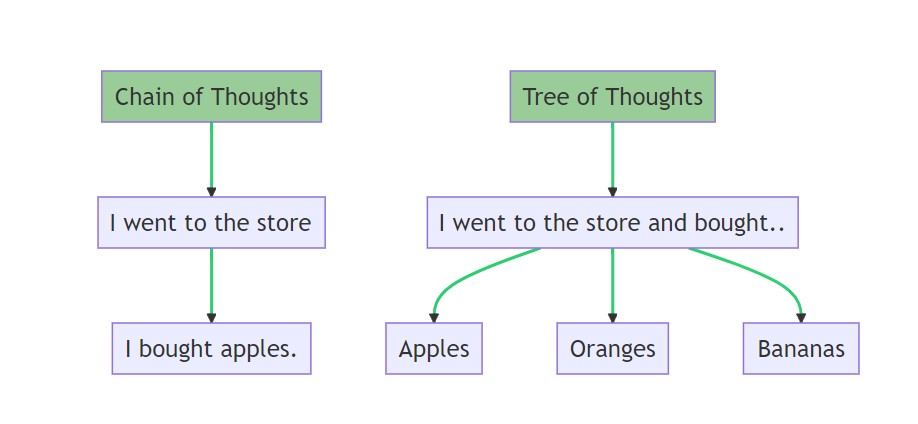

In [ ]:
level_1_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant"""),
    ("human", """
    Think about the topic the question is related to
    and give your thoughts on the topic in general :
    {query}
    Do not answer the question just generate your thoughts!
    """),
])

In [ ]:
level_1_chain = level_1_prompt | chat_model | StrOutputParser()

In [ ]:
level_1_chain.invoke({"query":"What happens to the pressure P of a ideal gas when the Temperature T is increased by afactor of 2 and the volume V is increased by a factor of 8?"})

"Ideal gases are a fundamental concept in physics and chemistry, and understanding their behavior is crucial in various fields. The ideal gas law, PV = nRT, is a simple yet powerful equation that relates the pressure (P), volume (V), number of moles (n), and temperature (T) of an ideal gas.\n\nWhen considering the effect of temperature and volume on pressure, it's essential to remember that the ideal gas law is a direct relationship between pressure and volume at constant temperature, and an inverse relationship between pressure and temperature at constant volume.\n\nIn this scenario, the temperature is increased by a factor of 2, which means the kinetic energy of the gas molecules will increase. This increase in kinetic energy will cause the molecules to move faster and collide more frequently with the container walls, resulting in an increase in pressure.\n\nOn the other hand, the volume is increased by a factor of 8, which means the container is expanded. This expansion will result 

In [ ]:
level_2_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant"""),
    ("human", """
    Think deeper and refine the thoughts provided below
    into important pointers to answer the question:
    Thoughts: {thoughts}
    Question: {query}
    Do not answer the question
    just Pointers using the thoughts provided to answer the question!
    """),
])

In [ ]:
level_2_chain = (RunnableAssign({"thoughts":level_1_chain}) |
                                level_2_prompt |
                                chat_model |
                                StrOutputParser()
)

In [ ]:
level_2_chain.invoke({"query":"What happens to the pressure P of a ideal gas when the Temperature T is increased by afactor of 2 and the volume V is increased by a factor of 8?"})

'Here are the refined pointers to answer the question:\n\n1. **Understanding the Ideal Gas Law**: The ideal gas law, PV = nRT, is a fundamental equation that relates the pressure (P), volume (V), number of moles (n), and temperature (T) of an ideal gas.\n\n2. **Relationship between Pressure and Temperature**: According to the ideal gas law, pressure (P) is directly proportional to temperature (T).\n\n3. **Effect of Temperature Increase**: If the temperature (T) is increased by a factor of 2, the pressure (P) will increase proportionally, assuming the volume (V) remains constant.\n\n4. **Relationship between Pressure and Volume**: The ideal gas law also states that pressure (P) is inversely proportional to volume (V).\n\n5. **Effect of Volume Increase**: If the volume (V) is increased by a factor of 8, the pressure (P) will decrease proportionally.\n\n6. **Combining the Effects**: The net effect on pressure (P) will be the combination of the increase due to temperature and the decrease 

In [ ]:
level_3_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant"""),
    ("human", """
    Answer the Question using the pointers given below related to the question
    Pointers: {pointers}
    Question: {query}
    Just answer the question do nothing else!
    """),
])

In [ ]:
full_chain =(
    RunnableAssign({"thoughts":level_1_chain}) |
    RunnableAssign({"pointers":level_2_chain}) |
    level_3_prompt|
    chat_model|
    StrOutputParser()
)

In [ ]:
full_chain.invoke({"query":"What happens to the pressure P of a ideal gas when the Temperature T is increased by afactor of 2 and the volume V is increased by a factor of 8?"})

'The pressure P of the ideal gas will decrease by a factor of 4.'

## Post Retrieval Stratergies

### Reranking

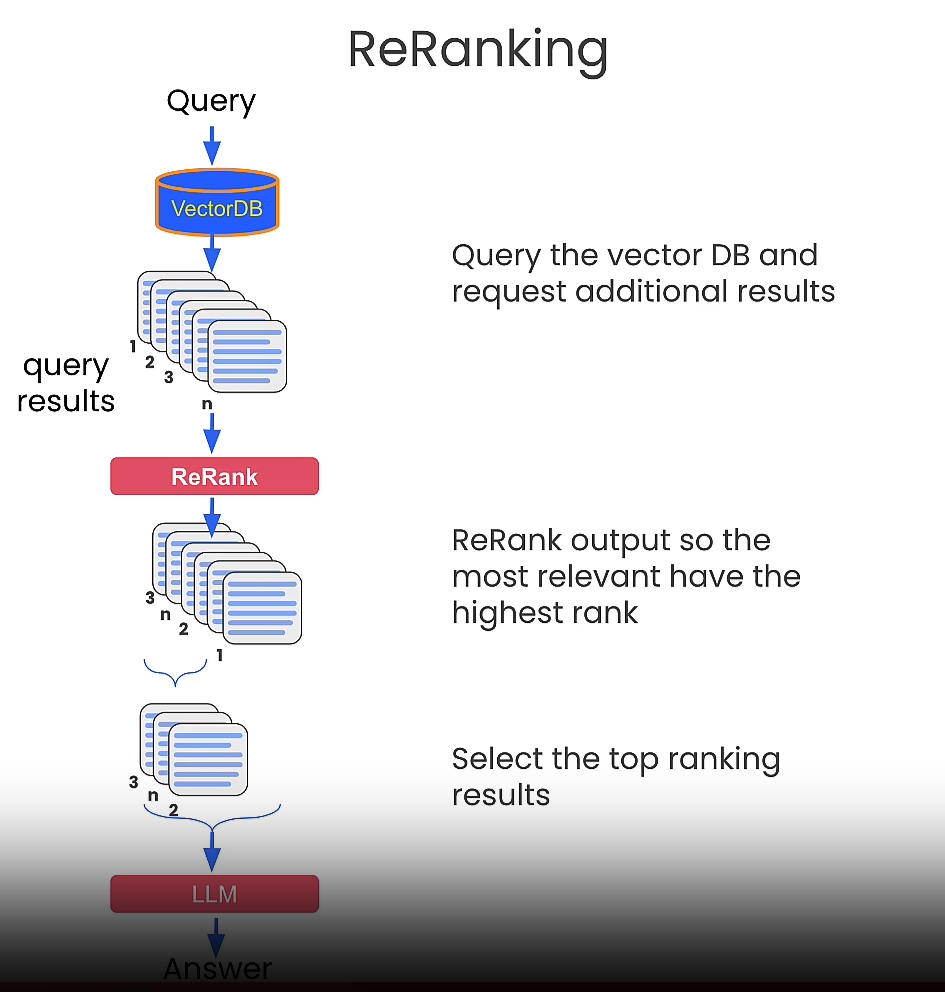

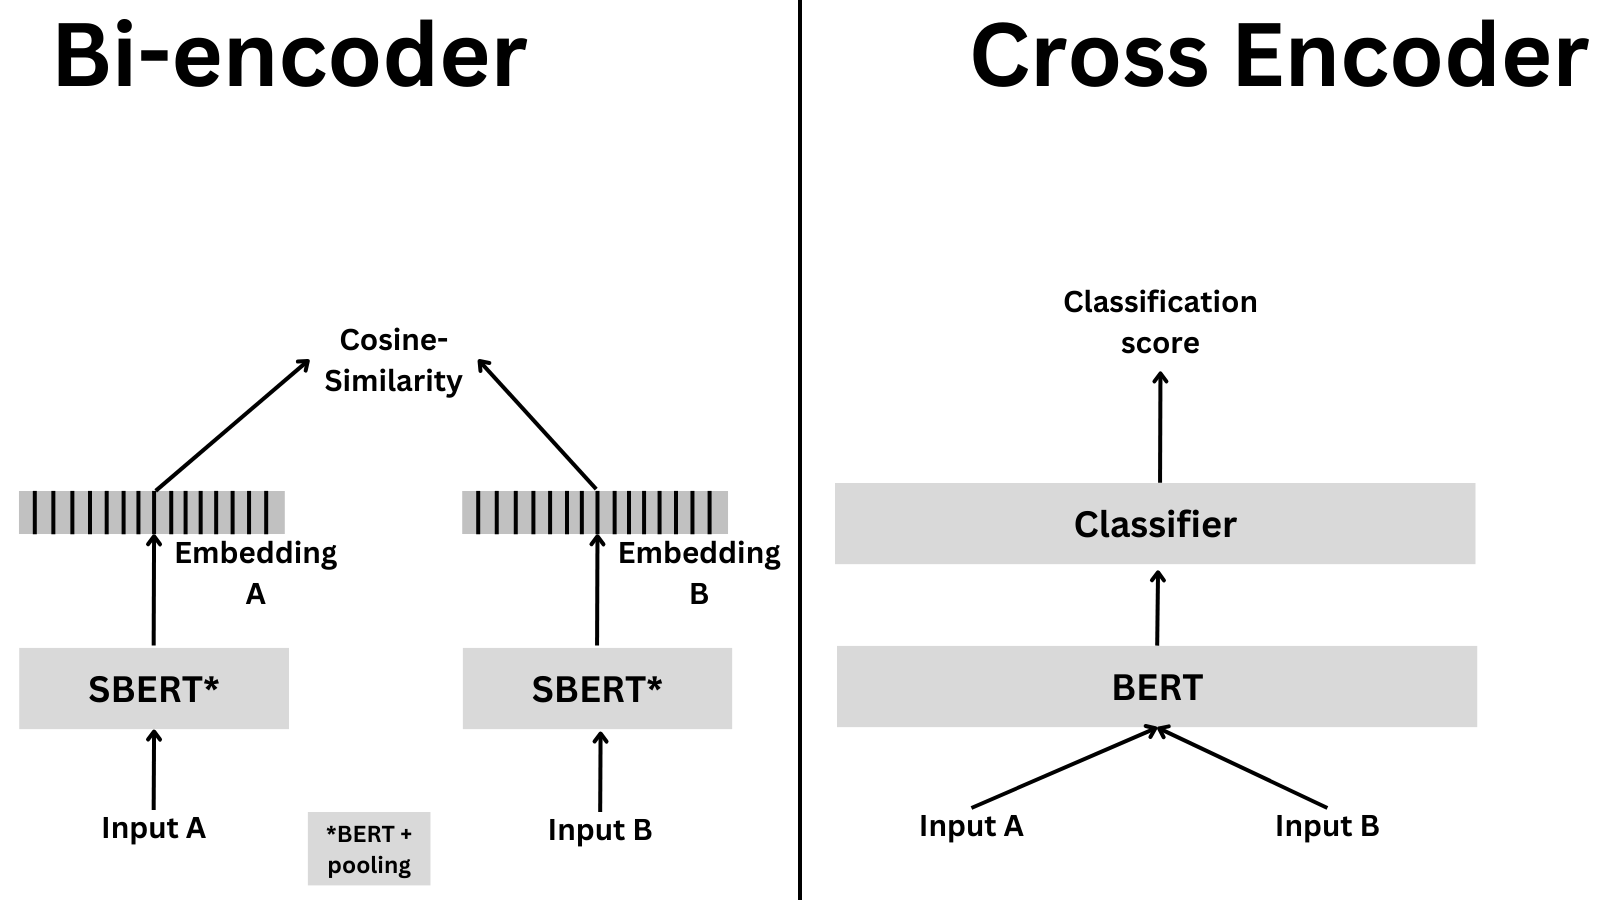

**Run With Caution You will need a GPU to run it!**

In [ ]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")
compressor = CrossEncoderReranker(model=model, top_n=3)

In [ ]:
compression_retriever = ContextualCompressionRetriever(base_compressor=compressor, base_retriever=retriever)

In [ ]:
def retrieve_and_rerank(state):
  query = state["query"]
  results = compression_retriever.invoke(query)
  return " ".join([doc.page_content for doc in results])

In [ ]:
reranking_chain = (RunnableAssign({"context":RunnableLambda(retrieve_and_rerank)}) |
         prompt |
         chat_model |
         StrOutputParser()
)

In [ ]:
chain.invoke({"query":"What is Deep seek R1? explain in short"})

## Hybrid Stratergies

### RAG Fusion

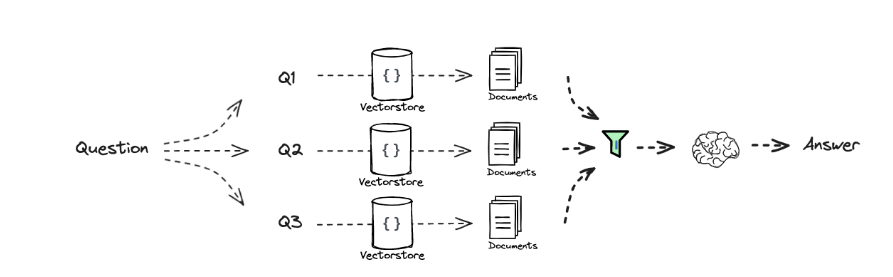

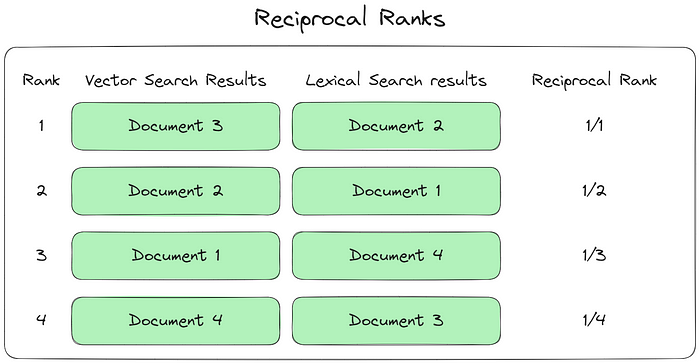

In [ ]:
prompt1 = ChatPromptTemplate.from_messages([
     ("system","""You are a helpful assistant that generates multiple search queries
     based on a single input."""),
     ("user", "Generate multiple search queries related to: {question}"),
     ("user", "Generate only questions and nothing else. OUTPUT (4 queries sperated by \n):")
 ])

In [ ]:
def check_empty(string):
    if string == " " or not string:
        return False
    else:
        return True

def split_questions(questions):
    q = questions.split("\n")
    return list(filter(check_empty,q))

In [ ]:
generate_queries = (
    prompt1 | chat_model | StrOutputParser() | RunnableLambda(split_questions)
)

In [ ]:
generate_queries.invoke({"question":"What is Deep seek R1? explain in short"})

['What is Deep Seek R1?',
 'What is the purpose of Deep Seek R1?',
 'What are the features of Deep Seek R1?',
 'What is the technology behind Deep Seek R1?']

In [ ]:
from langchain.load import dumps, loads


def reciprocal_rank_fusion(results: list[list], k=60):
    fused_scores = {}
    for docs in results:
        for rank, doc in enumerate(docs):
            doc_str = dumps(doc)
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            previous_score = fused_scores[doc_str]
            fused_scores[doc_str] += 1 / (rank + k)

    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]
    return " ".join([doc.page_content for doc, score in reranked_results])

In [ ]:
fusion_chain = generate_queries | retriever.map() | reciprocal_rank_fusion

In [ ]:
fusion_chain.invoke({"question":"""What is Deep seek R1? explain in short"""})

'the competition. For engineering-related tasks, DeepSeek-R1 performs slightly better than\nDeepSeek-V3, which could help developers in real world tasks.\n• Knowledge: On benchmarks such as MMLU, MMLU-Pro, and GPQA Diamond, DeepSeek-\nR1 achieves outstanding results, significantly outperforming DeepSeek-V3 with scores\nof 90.8% on MMLU, 84.0% on MMLU-Pro, and 71.5% on GPQA Diamond. While its\nperformance is slightly below that of OpenAI-o1-1217 on these benchmarks, DeepSeek-R1\nsurpasses other closed-source models, demonstrating its competitive edge in educational\ntasks. On the factual benchmark SimpleQA, DeepSeek-R1 outperforms DeepSeek-V3,\ndemonstrating its capability in handling fact-based queries. A similar trend is observed\nwhere OpenAI-o1 surpasses 4o on this benchmark.\n4 tuned models based on the same underlying checkpoints.\nIn the future, we plan to invest in research across the following directions for DeepSeek-R1.\n• General Capability:Currently, the capabilities of Deep

In [ ]:
gen_template = """
            You are a helpful, respectful and honest assistant designated answer questions.
            Answer the question based only on the following context.
            Context :{context}
            Question: {question}
           """
gen_prompt = ChatPromptTemplate.from_template(gen_template)

In [ ]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

In [ ]:
setup_retrieve = RunnableParallel(
    {
        "context":fusion_chain,
        "question":RunnablePassthrough()
    }
)

In [ ]:
RAG_fusion_chain = setup_retrieve|gen_prompt|chat_model|StrOutputParser()

In [ ]:
RAG_fusion_chain.invoke({"question":"What is Deep seek R1? explain in short"})

'DeepSeek-R1 is a model that performs slightly better than DeepSeek-V3 in engineering-related tasks. It achieves outstanding results on various benchmarks, such as MMLU, MMLU-Pro, and GPQA Diamond, and demonstrates its capability in handling fact-based queries.'

# Bonous: Implementing Tree of Thoughts